In [1]:
# Cell 1: Imports
import numpy as np
import torch

np.random.seed(59)  # reproducibility

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# Cell 2: Define grid and time parameters
nx, ny = 100, 100
n_nodes = nx * ny
n_features = 6
train_days = 100
test_days = 30

print("Nodes:", n_nodes)

Nodes: 10000


In [3]:
# Cell 3: Generate spatial grid
x_coords = np.linspace(0, 1, nx)
y_coords = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x_coords, y_coords)

# Flatten to node list
node_positions = np.column_stack([X.ravel(), Y.ravel()])

In [4]:
# Cell 4: Helper to generate smooth spatiotemporal fields
def generate_field(base, amp, freq_t, freq_x, freq_y, timesteps):
    """
    Create a synthetic field with sinusoidal variation in space and time.
    """
    t = np.arange(timesteps)
    field = np.zeros((timesteps, ny, nx))
    for i in range(timesteps):
        field[i] = (
            base
            + amp * np.sin(2 * np.pi * (freq_t * t[i] / timesteps
                                        + freq_x * X
                                        + freq_y * Y))
        )
    return field

In [5]:
# Cell 5: Generate predictor fields (plausible ranges)
timesteps_total = train_days + test_days

u_wind   = generate_field(5,  3,  2, 1, 1, timesteps_total)   # m/s
v_wind   = generate_field(2,  2,  3, 1, 2, timesteps_total)   # m/s
u_water  = generate_field(0.5, 0.3, 4, 2, 1, timesteps_total) # m/s
v_water  = generate_field(0.2, 0.2, 5, 1, 2, timesteps_total) # m/s
bed_shear= generate_field(0.1, 0.05, 6, 2, 2, timesteps_total) # N/m^2

# Soil particle size is static in time (random spatial variation)
d50 = 0.2 + 0.05 * np.random.rand(ny, nx)  # mm
d50 = np.broadcast_to(d50, (timesteps_total, ny, nx))

In [6]:
# Cell 6: Stack features into one array
features = np.stack([u_wind, v_wind, u_water, v_water, bed_shear, d50], axis=-1)
print("Features shape:", features.shape)  # (time, ny, nx, features)

Features shape: (130, 100, 100, 6)


In [8]:
# Cell 7: Generate labels (bed elevation field)
# Start with a sloping plane + sinusoidal perturbations
bed0 = 5 - 2 * X + 1 * np.sin(2*np.pi*Y)

labels = np.zeros((timesteps_total, ny, nx))
labels[0] = bed0

for t in range(1, timesteps_total):
    # Small erosion/accretion depending on water velocity & shear
    dz = -0.01 * u_water[t] * bed_shear[t] + 0.005 * v_water[t]
    labels[t] = labels[t-1] + dz

In [9]:
# Cell 8: Convert to training/testing tensors
train_X = torch.tensor(features[:train_days], dtype=torch.float32)
train_y = torch.tensor(labels[1:train_days+1], dtype=torch.float32)

test_X = torch.tensor(features[train_days:train_days+test_days], dtype=torch.float32)
test_y = torch.tensor(labels[train_days+1:train_days+test_days+1], dtype=torch.float32)

print("Train X:", train_X.shape)  # (time, ny, nx, features)
print("Train y:", train_y.shape)  # (time, ny, nx)
print("Test X:", test_X.shape)
print("Test y:", test_y.shape)

Train X: torch.Size([100, 100, 100, 6])
Train y: torch.Size([100, 100, 100])
Test X: torch.Size([30, 100, 100, 6])
Test y: torch.Size([29, 100, 100])


In [10]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# For now, use ground truth as "predictions" (replace with model outputs later)
pred_y = test_y.numpy()  # shape (time, ny, nx)

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(pred_y[0], cmap="terrain", origin="lower", animated=True)
ax.set_title("Day 0")

def update(frame):
    im.set_array(pred_y[frame])
    ax.set_title(f"Day {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig, update, frames=pred_y.shape[0], interval=500, blit=True, repeat=False
)

plt.close()  # Prevent duplicate static plot

from IPython.display import HTML
HTML(ani.to_jshtml())

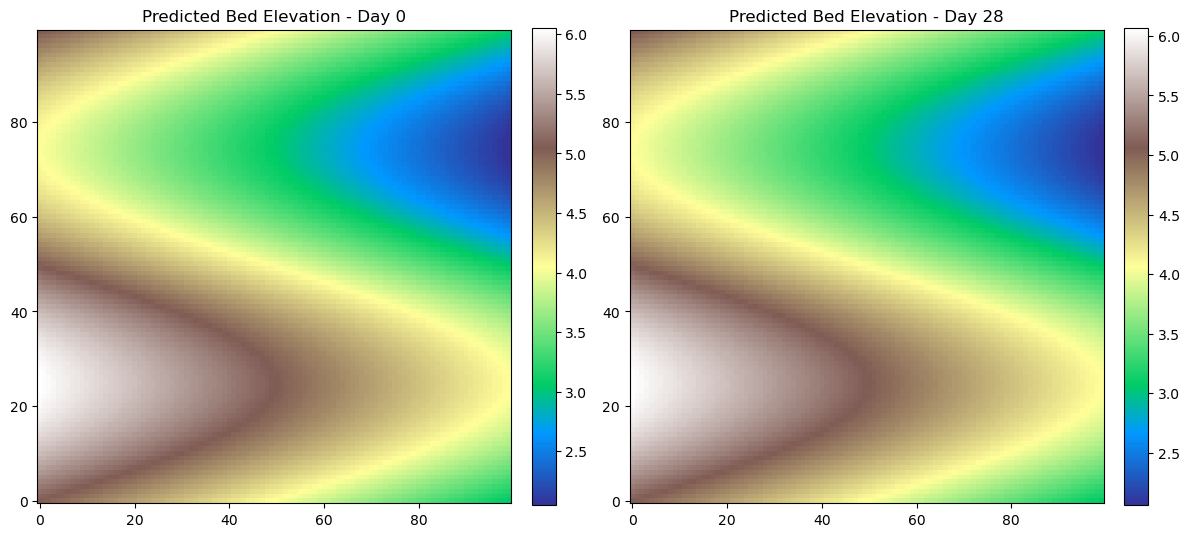

In [11]:
# Static snapshot comparison: Day 0 vs Day 30
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im1 = axes[0].imshow(pred_y[0], cmap="terrain", origin="lower")
axes[0].set_title("Predicted Bed Elevation - Day 0")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(pred_y[-1], cmap="terrain", origin="lower")
axes[1].set_title(f"Predicted Bed Elevation - Day {pred_y.shape[0]-1}")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()